In [167]:
from antares_devkit.models import BaseFilter
from antares_devkit.models import DevKitLocus
from antares_client import search
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import pandas as pd

In [454]:
t_now = Time.now()
day_mjd = t_now.mjd-150
print(t_now.mjd)

61185.74119744714


In [142]:

q_hamp_trans = {
    "query": {
        "bool": {
            "filter": [
                {
                    "range": {
                        "properties.newest_alert_observation_time": {
                            "gte": day_mjd,
                        }
                    }
                },
                {
                    "range": {
                        "properties.survey.lsst.dia_object_id": {
                            "gte": 1,
                        }
                    }
                },
                {
                     "term": {
                         "tags": "high_amplitude_transient_candidate"
                     }
                }
             ]
        }
    }
}

q_hamp_vstar = {
    "query": {
        "bool": {
            "filter": [
                {
                    "range": {
                        "properties.newest_alert_observation_time": {
                            "gte": day_mjd,
                        }
                    }
                },
                {
                    "range": {
                        "properties.survey.lsst.dia_object_id": {
                            "gte": 1,
                        }
                    }
                },
                {
                     "term": {
                         "tags": "high_amplitude_variable_star_candidate"
                     }
                }
             ]
        }
    }
}


In [143]:
hamp_trans = list(search.search(q_hamp_trans))
hamp_vstar = list(search.search(q_hamp_vstar))

In [333]:
# print(len(hamp_trans), len(hamp_vstar), t_now)

this is the number of loci that were tagged with high amp transient and variable star candidates within 20 days prior to the listed date. i want to use these as a small sample to perform some tests:
- what is the difference btwn the brightest mag and the reddest bright mag (in time and intensity)?
- how drastically does the slope change to exhibit this high amplitude change?
- are any of these quasars (cross match with million quasar catalog) and if so, do we have its spectra to look at?

im going to choose a random sample to do some tests on

In [350]:
trans_test = hamp_vstar[10].to_devkit()
trans_locus = DevKitLocus.model_validate(trans_test)

In [360]:
len(trans_test['alerts'])

134

In [290]:
# trans_lc = trans_locus.lightcurve()
# trans_lc
lsst_alerts = []
for alert in trans_locus.alerts:
    if alert.properties["ant_survey"] == 4:
        lsst_alerts.append(alert.properties)
print(lsst_alerts)

[{'lsst_observation_reason': 'ddf_cosmos', 'lsst_target_name': 'lowdust, ddf_cosmos', 'lsst_diaSource_diaSourceId': 313871014343737493, 'lsst_diaSource_visit': 2025121800201, 'lsst_diaSource_detector': 104, 'lsst_diaSource_diaObjectId': 313871014343737493, 'lsst_diaSource_ssObjectId': 0, 'lsst_diaSource_parentDiaSourceId': 0, 'lsst_diaSource_midpointMjdTai': 61028.32505456922, 'lsst_diaSource_ra': 149.85293156247985, 'lsst_diaSource_raErr': 2.2788784917793237e-05, 'lsst_diaSource_dec': 3.352736983727978, 'lsst_diaSource_decErr': 2.8474418286350556e-05, 'lsst_diaSource_ra_dec_Cov': -9.279684659579956e-11, 'lsst_diaSource_x': 4037.22998046875, 'lsst_diaSource_xErr': 0.5211484432220459, 'lsst_diaSource_y': 3553.10302734375, 'lsst_diaSource_yErr': 0.39917218685150146, 'lsst_diaSource_centroid_flag': False, 'lsst_diaSource_apFlux': 1049.7255859375, 'lsst_diaSource_apFluxErr': 352.7973937988281, 'lsst_diaSource_apFlux_flag': False, 'lsst_diaSource_apFlux_flag_apertureTruncated': False, 'lsst

In [413]:

lc_1 = {'g': {'ant_mjd': [], 'ABmag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}, 
         'r': {'ant_mjd': [], 'ABmag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}, 
         'i': {'ant_mjd': [], 'ABmag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}, 
         'z': {'ant_mjd': [], 'ABmag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []},
         'u': {'ant_mjd': [], 'ABmag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []},
         'y': {'ant_mjd': [], 'ABmag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}}
mag = []
magerr = []
mjd = []
for alert in lsst_alerts:
    band = alert['ant_passband']
    # lc_1[band]['ant_mag'].append(alert['ant_mag'])
    # lc_1[band]['ant_magerr'].append(alert['ant_magerr'])
    lc_1[band]['ant_mjd'].append(alert['ant_mjd'])
    lc_1[band]['lsst_diaSource_scienceFlux'].append(alert['lsst_diaSource_scienceFlux'])
    lc_1[band]['lsst_diaSource_scienceFluxErr'].append(alert['lsst_diaSource_scienceFluxErr'])
    mag = -2.5*np.log10(alert['lsst_diaSource_scienceFlux']) + 31.4
    lc_1[band]['ABmag'].append(mag)

now, i tried to retrieve the ant_mag_corrected from this locus, but for some reason i recieved an error when i tried to call alert['ant_mag_corrected']. how was this object tagged with this filter if the filter used ant_mag_corrected to det the mag values? what does this mean for the other objects, and for objects not tagged with this filter? idk :/// i will instead calculate the mag myself using [the eqn suggested by the lsst team](https://dp1.lsst.io/tutorials/portal/103/portal-103-3.html) (which is just the astropy flux in nJy to AB mag function)

In [414]:
print(min(lc_1['g']['ABmag']), min(lc_1['r']['ABmag']), min(lc_1['i']['ABmag']), min(lc_1['z']['ABmag']), min(lc_1['u']['ABmag']), min(lc_1['y']['ABmag']))

21.57702127435482 20.602173015992776 18.614011384748714 17.66337428211293 21.39247149477343 17.17145893390883


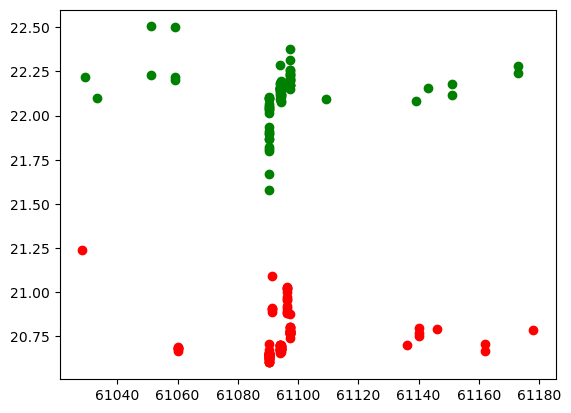

In [415]:

plt.scatter(lc_1['g']['ant_mjd'], lc_1['g']['ABmag'], color='g')
plt.scatter(lc_1['r']['ant_mjd'], lc_1['r']['ABmag'], color='r')
# plt.errorbar(lc_1['g']['ant_mjd'], lc_1['g']['ant_mag'], yerr=lc_1['g']['ant_magerr'], color='k', fmt='o')
# plt.ylim(18.9, 17.7)

In [287]:
mag

array([22.10502899, 22.10039651, 22.09137969, 22.10538509, 21.93741525,
       22.10459954, 22.0986813 , 22.10176463, 22.10059202, 22.09883488,
       22.09895537, 21.82918566, 22.11556744, 22.14443546, 22.13013069,
       21.94486572, 22.13237801, 22.11514372, 22.09724386, 22.11606784,
       22.08721085, 22.09455593, 22.08636235, 22.08003385, 22.08818496,
       22.08303325, 22.07880185, 22.08802051, 22.08758923, 22.09612667,
       22.06441122, 22.13323362, 22.10022188, 22.09435834, 22.10682799,
       22.10979602, 22.09736382, 22.08423219, 22.09782906, 22.09841171,
       22.10951461, 22.10295658, 21.6376731 , 22.08789133, 22.0986583 ,
       22.0870321 , 22.08853215, 22.06803936, 22.08242772, 22.09305844,
       22.10526292, 22.08549235, 22.08179197, 22.09921672, 22.08605198,
       22.08662404, 22.08983136, 22.08493901, 22.08511088, 22.07491539,
       22.07947364, 22.07562583, 22.08442441])

In [213]:
lc = trans_lc.group_by("ant_survey")

lc.groups.keys

ant_survey
int64
1
2


i am trying to seperate out the obervations to just lsst observations, but for some reason the the lightcurve none of the rows have ant_survey = 4 (which is what is would be for LSST)

In [159]:
lsst_obs_count = 0
for alert in trans_test['alerts']:
    if alert['properties']['ant_survey'] == 4:
        lsst_obs_count += 1
print(lsst_obs_count)

673


i want to look at the difference in the brightest mag and the brightest red mag (in intensity and in time), i am worried that the way im getting the variables will exclude any forced photometry and only have values from alert packets, but theoretically since these are the extremes for those bands they should exist in alert packets anyways so it should be fine for this test

In [404]:
trans_test

{'id': 'ANT2022f1wg9fq4f1b2',
 'ra': 150.35920484632837,
 'dec': 2.4567438094870937,
 'user_tags': ['in_LSSTDDF', 'high_amplitude_variable_star_candidate'],
 'old_properties': {'num_alerts': 134,
  'num_mag_values': 81,
  'brightest_alert_id': 'ztf_candidate:2471533560815015044',
  'brightest_alert_magnitude': 17.13202667236328,
  'brightest_alert_observation_time': 60225.53356479993,
  'newest_alert_id': 'lsst:170050503566164140',
  'newest_alert_magnitude': 21.082220438243787,
  'newest_alert_observation_time': 61095.16411102216,
  'oldest_alert_id': 'ztf_candidate:2110520870815010034',
  'oldest_alert_magnitude': 18.30181121826172,
  'oldest_alert_observation_time': 59864.5208796002,
  'is_corrected': 'true',
  'ztf_object_id': 'ZTF18acrmmyu',
  'ztf_ssnamenr': 'null',
  'survey': {'ztf': {'id': ['ZTF18acrmmyu'],
    'rcid': [8],
    'field': [468],
    'ssnamenr': ['null']},
   'lsst': {'dia_object_id': ['170028512534069284'], 'ss_object_id': []}}},
 'catalog_objects': {},
 'grav_w

In [446]:
hamp_cands = hamp_trans + hamp_vstar
g_r_table = pd.DataFrame(columns = ['ant_id', 'dia_oid', 'g_mjd', 'g_mag', 'r_mjd', 'r_mag', 'g_r_mjd', 'g_r_mag'])

for cand in hamp_cands:
    now_cand = cand.to_devkit()
    alerts = now_cand['alerts']
    mag_max = {'g': [0, 0, 0], 'r': [0, 0, 0], 'i': [0, 0, 0], 'z': [0, 0, 0], 
               'u': [0, 0, 0], 'y': [0, 0, 0]} # [mjd, flux/mag, err]
    ant_id = now_cand['id']
    for alert in alerts:
        if 'lsst' not in alert['id']:
            continue
        band = alert['properties']['lsst_diaSource_band']
        dia_oid = alert['properties']['lsst_diaSource_diaObjectId']
        if mag_max[band][1] < alert['properties']['lsst_diaSource_scienceFlux']: # set as highest flux value
            mag_max[band][1] = alert['properties']['lsst_diaSource_scienceFlux']
            mag_max[band][0] = alert['properties']['lsst_diaSource_midpointMjdTai']
            
    if mag_max['g'][1] == 0 or mag_max['r'][1] == 0: #exclude dia oids w/out flux measurements in g or r
        continue
        
    mag_max['g'][1] = -2.5*np.log10(mag_max['g'][1])+31.4
    mag_max['r'][1] = -2.5*np.log10(mag_max['r'][1])+31.4
    row = [ant_id, dia_oid, mag_max['g'][0], mag_max['g'][1], mag_max['r'][0], mag_max['r'][1], 
           mag_max['g'][0] - mag_max['r'][0], mag_max['g'][1] - mag_max['r'][1]]
    g_r_table.loc[len(g_r_table)] = row
print(len(hamp_cands), len(g_r_table))
g_r_table

51 23


,ant_id,dia_oid,g_mjd,g_mag,r_mjd,r_mag,g_r_mjd,g_r_mag
0,ANT20239nfed520dxje,313875415045767194,61090.223992,18.357178,61090.339726,17.743496,-0.115734,0.613683
1,ANT2020alwm2,170028526464401600,61091.269145,18.383052,61090.335674,18.200868,0.933471,0.182185
2,ANT202386ye2waqmqpf,170345139485016180,61090.227725,18.088617,61090.207120,17.341607,0.020605,0.747010
3,ANT2023q6hwmp481mvb,170028528912826419,61094.203913,19.026960,61091.274768,17.437671,2.929146,1.589289
4,ANT2024phjoemnsiodb,170028526852374631,61090.324426,21.795980,61090.338079,21.581115,-0.013653,0.214866
5,ANT2021aedgx2a,170028526451294222,61094.212987,16.054796,61095.189112,15.397227,-0.976125,0.657569
6,ANT202448dk5jz9tu7z,170028529317052506,61091.269614,23.710494,61090.267572,24.247354,1.002042,-0.536860
7,ANT2020plvcq,170028511450366073,61091.210659,17.288666,61090.244971,16.518903,0.965687,0.769763
8,ANT2021liuya,170028529022926925,61090.326747,17.383429,61090.266639,16.805629,0.060109,0.577799
9,ANT20216sez6,170028526740701214,61090.324426,18.190488,61090.332412,17.600992,-0.007986,0.589496


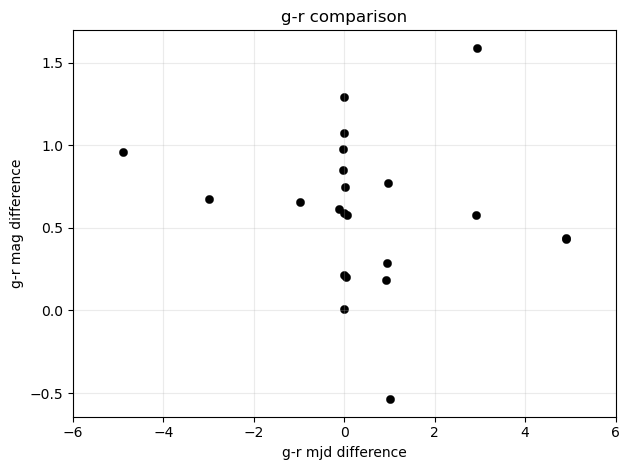

In [443]:
plt.scatter(g_r_table['g_r_mjd'], g_r_table['g_r_mag'], color='k', lw=0.25)
plt.xlabel('g-r mjd difference')
plt.ylabel('g-r mag difference')
plt.title('g-r comparison')
plt.xlim([-6,6])
# plt.semilogy()
plt.grid(alpha=0.25)
plt.tight_layout()

this sample is: objects with the high amplitude tag (both variable star and transient tags) that have at least one lsst measurement in both the g and r bands. i use the g band to det when the obj is brightest in general. also, i excluding the obj with a 75 day change in the graph to see the pattern of the majority of objects better. 

i am comparing the time and magnitude difference for when the objects show they are brightest and reddest. we can see that for most objects, these occur within a day of each other (at least, as measured by lsst). i cant see much of a pattern from this, the under 1 day objects have a large range of mag difference, and while most objs with multiple days between have a more intense change, its not consistent. i wonder if the brightness in general affects how drastic the difference is? 

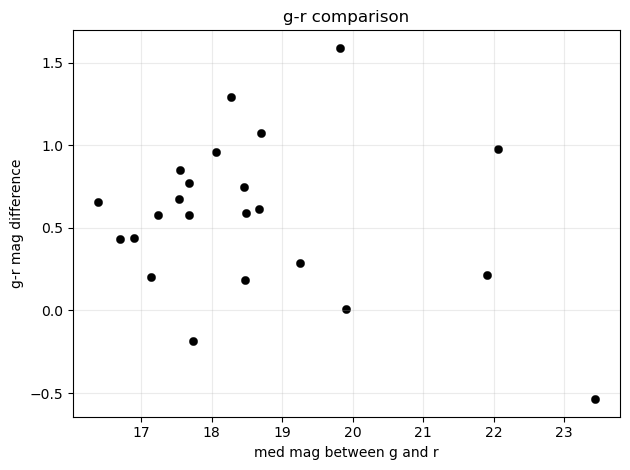

In [441]:
plt.scatter(0.5*g_r_table['g_r_mag']+g_r_table['g_mag'], g_r_table['g_r_mag'], color='k', lw=0.25)
plt.xlabel('med mag between g and r')
plt.ylabel('g-r mag difference')
plt.title('g-r comparison')
# plt.semilogy()
plt.grid(alpha=0.25)
plt.tight_layout()

i think its interesting that the faintest obj is the obj that has biggest negative g-r mag difference, was redder first and then brighter? i dont think THATS what this mean, especially since when i look at its [lightcurve](https://antares.noirlab.edu/loci/ANT202448dk5jz9tu7z) the mag values seem about constant throughout all bands.... hm ://

so, what do both of these graphs actually mean for the objects? does this indicate anything at all ? after looking through some of the lightcurves of these objects, it is clear that some of these values dont mean anything. ex, [obj 1](https://antares.noirlab.edu/loci/ANT2022kphkzk3jjpmn), near 0 for both change in mag and mjd, only has lsst measurements for that day, it is clear it passed through the tag filter based on its ztf measurements. 

i think i need to make my own version of Morganson 2015's V variable to determine the variability of the objs using only (or primarily) lsst measurements, i just worry about the efficancy due to how few and how inconsistent of measurements most objs have from lsst. im also worry that im jacking their shit instead of making my own thing, but is that okay? i have to build on those before me so? im also unsure because V looks at the overall variability, and has no component to ensure recency in the variability, but maybe i use it as a base and build from that. yea